# <center> DATASET ANALYSIS <center> 

This notebook is aimed to analyze and visualize the characteristic features of our dataset and the obtained results using OriGENE

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# ROC curve and AUC:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import roc_auc_score


matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})



#from matplotlib import rc

# Plot settings
#rc('font',**{'family':'sans-serif','sans-serif':['Computer Modern Sans Serif']})
#rc('font',**{'family':'serif','serif':['Times']})
#rc('text', usetex=True)

In [2]:
PATH = '/home/william/marc/marc_directory/OriGENE_paper/Spreadsheets/'
filename = 'CD_Binary_All_CGCv.96.csv'

In [3]:
def OG_TSG_NG_reader(filename,PATH):
    
    """
    This function is aimed to read the content of the table in the file OG_TSG_NG*.
    
                                      __________ Inputs_____________
    
    PATH: path to where the csv file is.
    filename: name of the file
    
    Examples:
    
                                      _________ Outputs ____________

    """ 
    
    with open(PATH+filename,'r') as inputFile: 
        Comparative_array = []
        for line in inputFile.readlines():
            splitline = line.split() # Lists of type [chr,beginning,end,value]
            print(splitline)
            if line[0] != '#':
                row = []
                chr_split = splitline[2].split(':')
                print(chr_split)
                chr_num = chr_split[0]
                basepairs = chr_split[1].split('-') # Range in basepairs of the chromosome, separated first and last
                first_basepair = int(basepairs[0].replace(',',''))
                last_basepair = int(basepairs[1].replace(',',''))
                gene_length = last_basepair-first_basepair
                row.append(splitline[1])
                row.append(chr_num)
                row.append(gene_length)
                row.append(splitline[4])
                Comparative_array.append(row)
            
    return np.array(Comparative_array, dtype=object)

In [4]:
Comparative_array = OG_TSG_NG_reader(filename,PATH)

['#Gene', 'Label', 'Location', 'Source', 'Strand']
['A1CF', 'CD', 'chr10:50799421-50885675', 'CGC_v.96', 'neg']
['chr10', '50799421-50885675']
['ABI1', 'CD', 'chr10:26746593-26860935', 'CGC_v.96', 'neg']
['chr10', '26746593-26860935']
['ABL1', 'CD', 'chr9:130713946-130885683', 'CGC_v.96', 'pos']
['chr9', '130713946-130885683']
['ABL2', 'CD', 'chr1:179099327-179229601', 'CGC_v.96', 'neg']
['chr1', '179099327-179229601']
['ACKR3', 'CD', 'chr2:236569641-236582358', 'CGC_v.96', 'pos']
['chr2', '236569641-236582358']
['ACSL3', 'CD', 'chr2:222860934-222944639', 'CGC_v.96', 'pos']
['chr2', '222860934-222944639']
['ACSL6', 'CD', 'chr5:131949973-132011662', 'CGC_v.96', 'neg']
['chr5', '131949973-132011662']
['ACVR1', 'CD', 'chr2:157736444-157875111', 'CGC_v.96', 'neg']
['chr2', '157736444-157875111']
['ACVR1B', 'CD', 'chr12:51951701-51994217', 'CGC_v.96', 'pos']
['chr12', '51951701-51994217']
['ACVR2A', 'CD', 'chr2:147844517-147930824', 'CGC_v.96', 'pos']
['chr2', '147844517-147930824']
['AFDN'

['chr17', '40819122-40836266']
['HAUS8', 'NG', 'chr19:17049729-17075452', 'DORGE', 'neg']
['chr19', '17049729-17075452']
['ZNF792', 'NG', 'chr19:34956354-34964229', 'DORGE', 'neg']
['chr19', '34956354-34964229']
['ZNF597', 'NG', 'chr16:3432414-3443504', 'DORGE', 'pos']
['chr16', '3432414-3443504']
['VMA21', 'NG', 'chrX:151397206-151409364', 'DORGE', 'pos']
['chrX', '151397206-151409364']
['C19ORF26', 'NG', 'chr19:1228287-1238027', 'DORGE', 'neg']
['chr19', '1228287-1238027']
['PPOX', 'NG', 'chr1:161166410-161171218', 'DORGE', 'pos']
['chr1', '161166410-161171218']
['GDF6', 'NG', 'chr8:96142333-96160806', 'DORGE', 'neg']
['chr8', '96142333-96160806']
['ABHD8', 'NG', 'chr19:17292131-17303425', 'DORGE', 'neg']
['chr19', '17292131-17303425']
['MYL6B', 'NG', 'chr12:56152256-56157982', 'DORGE', 'pos']
['chr12', '56152256-56157982']
['SLC36A4', 'NG', 'chr11:93144174-93197991', 'DORGE', 'neg']
['chr11', '93144174-93197991']
['FKBP7', 'NG', 'chr2:178463664-178478600', 'DORGE', 'neg']
['chr2', '

### <center> Gene length distribution for each class <center>

In [5]:
nG = len(Comparative_array[:,0])
nCD = len(np.where(Comparative_array[:,0] == 'CD')[0])
nNG = len(np.where(Comparative_array[:,0] == 'NG')[0])

print('Total number of genes:',nG)
print('Number of cancer drivers:',nCD)
print('Number of normal genes:',nNG)


CD_lengths = Comparative_array[:,2][np.where(Comparative_array[:,0] == 'CD')[0]]
NG_lengths = Comparative_array[:,2][np.where(Comparative_array[:,0] == 'NG')[0]]

max_CD = np.max(CD_lengths)
max_NG = np.max(NG_lengths)
xmin = 0
xmax = 500000

binwidth = 100

Total number of genes: 1454
Number of cancer drivers: 727
Number of normal genes: 727


In [6]:
histogram = Comparative_array[np.where(Comparative_array[:,0] == 'OG'),2][0]

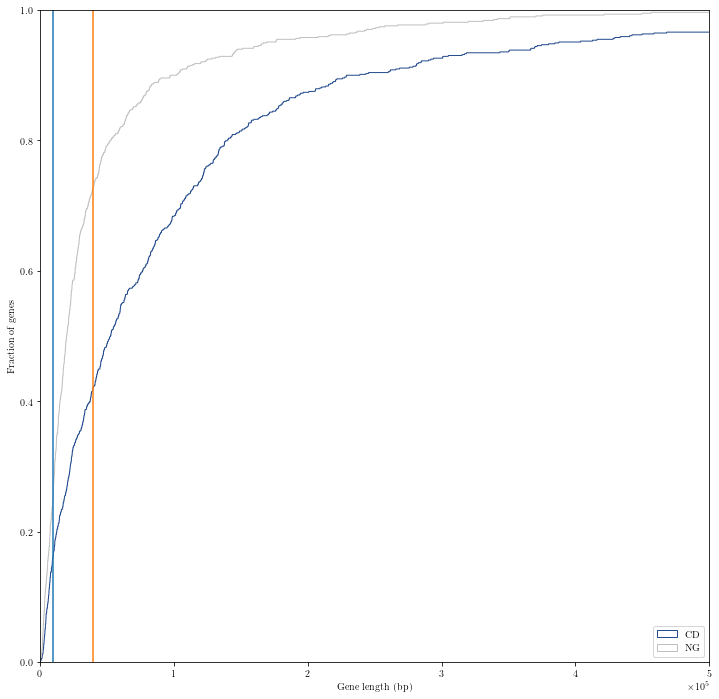

In [7]:
# Cumulative distribution of gene length

plt.figure(figsize=(12,12))
#plt.title('Cumulative distribution for the gene length in Training and Validation')
plt.xlabel('Gene length (bp)')
plt.ylabel('Fraction of genes')
plt.hist(CD_lengths, bins = np.arange(0,max_CD,binwidth),density=True, histtype='step', cumulative=True, color='#234b8d', label='CD')
plt.hist(NG_lengths,bins = np.arange(0,max_NG,binwidth),density=True, histtype='step', cumulative=True, color='silver',label='NG')
plt.xlim(xmin,xmax)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend(loc='lower right')
plt.plot(10000*np.ones(16),np.linspace(0,1,16))
plt.plot(40000*np.ones(16),np.linspace(0,1,16))
plt.ylim(0,1)
plt.savefig('Cumulative_length.png', dpi=500, bbox_inches='tight')
#plt.savefig('Cumulative_length.png')
plt.show()


#plt.figure(figsize=(8,8))
#plt.style.use('seaborn-deep')
#plt.title('Gene length histogram')
#plt.xlabel('Gene length (bp)')
#plt.ylabel('Number of genes')
#plt.hist([TSG_lengths,OG_lengths,NG_lengths], bins = np.arange(0,max_TSG,binwidth), density = False, histtype = 'bar', label=['TSG','OG','NG'])
#plt.hist(OG_lengths, bins = np.arange(0,max_OG,binwidth), density = False, histtype = 'bar',alpha = 0.5, label='OG')
#plt.hist(NG_lengths, bins = np.arange(0,max_NG,binwidth), density = False, histtype = 'bar',alpha = 0.5, label='NG')
#plt.xlim(xmin,xmax)
#plt.legend()
#plt.savefig('Bars.png')
#plt.xlim(xmin,xmax)
#plt.ylim(ymin,ymax)
#plt.show()

## <center> DNA strand (positive, negative) distribution for each class <center>

In [8]:
npos = len(np.where(Comparative_array[:,3] == 'pos')[0])
nneg = len(np.where(Comparative_array[:,3] == 'neg')[0])

Strand_list = ['pos','neg']
Label_list = ['CD','NG']
clist = ['#234b8d','#996c1e']

chr_list = ['chr{}'.format(i) for i in range(1,23)]
chr_list.append('chrX')

chrom_distr = {}


for label in Label_list:
    for strand in Strand_list:
        number = len(Comparative_array[(Comparative_array[:,0] == label) & (Comparative_array[:,3]== strand)])
        print('Number of '+label+' in the '+strand+' strand:', number)
    numberlist = []
    for chromosome in chr_list:
        number = len(Comparative_array[(Comparative_array[:,0] == label) & (Comparative_array[:,1]== chromosome)])
        numberlist.append(number)
    chrom_distr[label] = numberlist
    
plt.show()
print(chrom_distr)

Number of CD in the pos strand: 367
Number of CD in the neg strand: 360
Number of NG in the pos strand: 389
Number of NG in the neg strand: 338
{'CD': [67, 49, 50, 23, 27, 38, 36, 34, 31, 30, 38, 46, 14, 21, 20, 28, 45, 9, 42, 14, 5, 19, 41], 'NG': [74, 55, 44, 39, 14, 36, 40, 22, 18, 21, 26, 33, 15, 7, 12, 31, 31, 8, 124, 15, 9, 15, 38]}


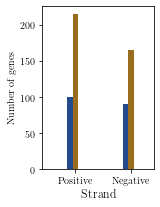

In [9]:
strand_distribution = {'CD':[100,90], 'NG':[215,165]}
Strand_list = ['Positive', 'Negative']
plt.figure(figsize=(2,3))
for i,label in enumerate(Label_list):
    plt.bar(np.arange(1+i*.2,4+i*.2,2),strand_distribution[label],width=.2,label = label,color = clist[i])
#plt.legend(loc='upper right', fontsize = 'x-small')
plt.xlabel('Strand', size=12)
plt.xlim(0,4)
plt.xticks(np.arange(1+0.2,4+0.2,2), Strand_list)  # Set text labels.
plt.ylabel('Number of genes')
plt.savefig('Strand_distribution.png', dpi=1000, bbox_inches='tight')
plt.show()

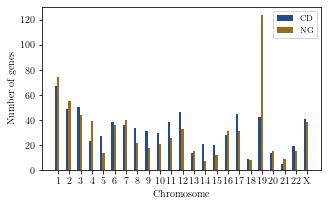

In [10]:
plt.figure(figsize=(5,3))
for i,label in enumerate(Label_list):
    plt.bar(np.arange(1+i*.20,24+i*.20,1),chrom_distr[label],width=.20,label = label,color = clist[i])
plt.legend(loc='upper right', fontsize = 'small')
plt.xlabel('Chromosome')
plt.xticks(np.arange(1+0.20,24+0.20,1), ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','X'])  # Set text labels.
plt.ylabel('Number of genes')
plt.savefig('Chr_distribution.png', dpi=1000, bbox_inches='tight')
plt.show()

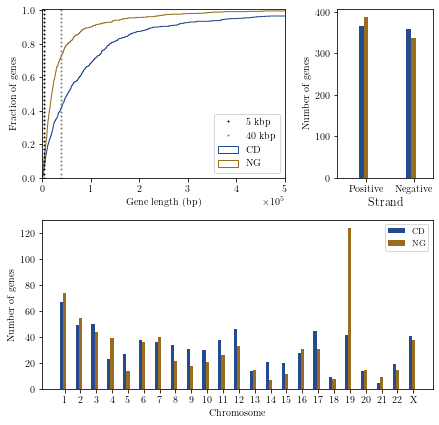

In [17]:
# Initialize the grid
plt.figure(figsize=(7,7))
grid = plt.GridSpec(2, 3, wspace=0.55, hspace=0.25)
# make subplots
plt.subplot(grid[0, :2])
#plt.title('Cumulative distribution for the gene length in Training and Validation')
plt.xlabel('Gene length (bp)')
plt.ylabel('Fraction of genes')
plt.plot(5000*np.ones(50),np.linspace(0,1.2,50), color = 'black', marker = 'o', markersize = 1,label = '5 kbp', lw = 0)
plt.plot(40000*np.ones(50),np.linspace(0,1.2,50), color = 'grey', marker = 'o',markersize=1, label = '40 kbp', lw = 0)
plt.hist(CD_lengths, bins = np.arange(0,max_CD,binwidth),density=True, histtype='step', cumulative=True, color=clist[0], label='CD')
plt.hist(NG_lengths,bins = np.arange(0,max_NG,binwidth),density=True, histtype='step', cumulative=True, color=clist[1],label='NG')
plt.xlim(xmin,xmax)
plt.ylim(0,1.01)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend(loc='lower right')
#plt.ylim(ymin,nNG)
#plt.savefig('Cumulative_length.png', dpi=500, bbox_inches='tight')
#plt.savefig('Cumulative_length.png')


plt.subplot(grid[0, 2])
strand_distribution = {'CD':[367,360], 'NG':[389,338]}
Strand_list = ['Positive', 'Negative']

for i,label in enumerate(Label_list):
    plt.bar(np.arange(1+i*.2,4+i*.2,2),strand_distribution[label],width=.2,label = label,color = clist[i])
#plt.legend(loc='upper right', fontsize = 'x-small')
plt.xlabel('Strand', size=12)
plt.xlim(0,4)
plt.xticks(np.arange(1+0.2,4+0.2,2), Strand_list)  # Set text labels.
plt.ylabel('Number of genes')
#plt.savefig('Strand_distribution.png', dpi=1000, bbox_inches='tight')

plt.subplot(grid[1, :])

for i,label in enumerate(Label_list):
    plt.bar(np.arange(1+i*.20,24+i*.20,1),chrom_distr[label],width=.20,label = label,color = clist[i])
plt.legend(loc='upper right', fontsize = 'small')
plt.xlabel('Chromosome')
plt.xticks(np.arange(1+0.20,24+0.20,1), ['1','2','3','4','5','6','7','8','9','10','11','12','13','14','15','16','17','18','19','20','21','22','X'])  # Set text labels.
plt.ylabel('Number of genes')
plt.savefig('Final_overview.png', dpi=1000, bbox_inches='tight')

plt.show()

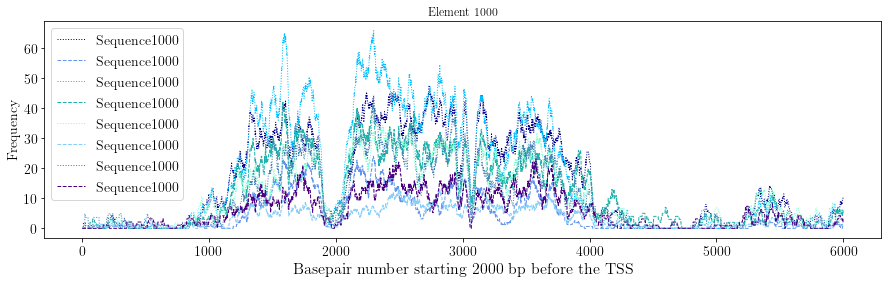

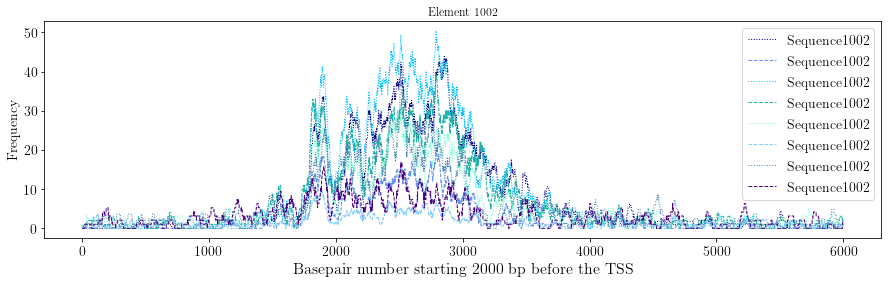

In [34]:
# Final sequences illustrated
track_list = [' Normal',' Cancer']

color_list = ['darkblue','cornflowerblue','deepskyblue','lightseagreen', 'aquamarine', 'lightskyblue', 'steelblue', 'indigo']
ls_list = ['dotted','dashed']
PATH = '/scratch/lema/marc/oncogenes/GSE67471/Final_sequences/'

labels = ['Liver_I', 'Liver_II', 'Lung_I', 'Lung_II']

name_list = [PATH+'Final_sequences_40kbp_{}.npy'.format(label) for label in labels]

  
for element in range(1000,1004,2): #(len(Position)):
    plt.figure(figsize=(15,4))
    plt.title('Element {}'.format(element))
    j = 0
    for f,label in enumerate(labels):
        xtrn = np.load(PATH+'Final_sequences_40kbp_{}.npy'.format(label))
####################### Plotting the final cropped and resampled input signals: ####################################
        #plt.title(title)
        for i,track in enumerate(track_list):
            plt.plot(np.arange(len(xtrn[element,:6000,i])),xtrn[element,:6000,i], color= color_list[j], ls = ls_list[i], alpha=1, lw = 1, label = 'Sequence'+str(element))
            j += 1
    plt.xlabel('Basepair number starting 2000 bp before the TSS',fontsize=16)
    plt.ylabel('Frequency',fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
        #plt.xlim((0,maxpos))
    plt.legend(fontsize=14)
    #plt.savefig('/home/william/marc/Pictures/Original_signal_{}.png'.format(element), dpi=100, bbox_inches='tight')
    plt.show()


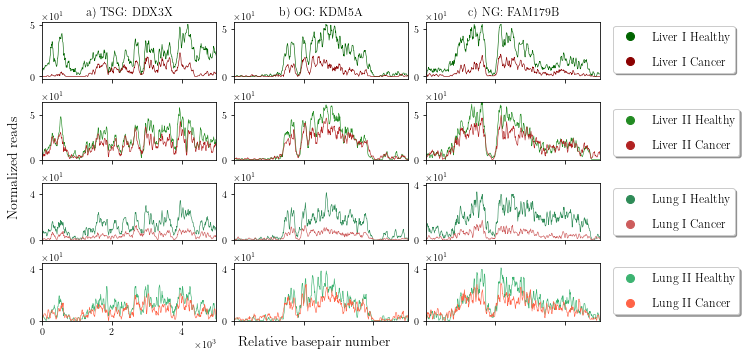

In [21]:
import matplotlib.lines as mlines

# Handles

livI_healthy = mlines.Line2D([], [], color='darkgreen', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Liver','I','Healthy'))
livI_cancer = mlines.Line2D([], [], color='darkred', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Liver','I','Cancer'))
livII_healthy = mlines.Line2D([], [], color='forestgreen', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Liver','II','Healthy'))
livII_cancer = mlines.Line2D([], [], color='firebrick', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Liver','II','Cancer'))
lunI_healthy = mlines.Line2D([], [], color='seagreen', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Lung','I','Healthy'))
lunI_cancer = mlines.Line2D([], [], color='indianred', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Lung','I','Cancer'))
lunII_healthy = mlines.Line2D([], [], color='mediumseagreen', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Lung','II','Healthy'))
lunII_cancer = mlines.Line2D([], [], color='tomato', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Lung','II', 'Cancer'))




fig = plt.figure(figsize=(10,5.5))
plt.ticklabel_format(style='sci', scilimits=(0,0))
grid = plt.GridSpec(4, 3, wspace=.1, hspace=0.4 )
last_bp = 5000
step = 10
lw =.7

# TSG:

xtrn = np.load(name_list[0])
plt.subplot(grid[0, 0])

element= 312
plt.title('a) TSG: DDX3X')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0], color = 'darkgreen', alpha = 1., lw = 0.6, label = 'Liver I healthy')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1], color = 'darkred', alpha = 1., lw = 0.6, label = 'Liver I cancer')
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))

plt.subplot(grid[0, 1])
element = 600
plt.title('b) OG: KDM5A')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0],  color = 'darkgreen', alpha = 1., lw = 0.6, label = '')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1],color = 'darkred', alpha = 1., lw = 0.6, label = '')
#plt.yticks([0,400])
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))

plt.subplot(grid[0, 2])
element= 397
plt.title('c) NG: FAM179B')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0], color = 'darkgreen', alpha = 1., lw = 0.6, label = '')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1], color = 'darkred', alpha = 1., lw = 0.6, label = '')
#plt.yticks([0,400])
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))


#################################################################

xtrn = np.load(name_list[1])

plt.subplot(grid[1, 0])
element= 312
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0], color = 'forestgreen', alpha=1., lw =0.6, label = 'Liver II healthy')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1], color = 'firebrick', alpha=1., lw =0.6, label = 'Liver II cancer')

plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.yticks(ticks=[0,50])
plt.xlim((0,5000))
plt.ylim((0,65))


plt.subplot(grid[1, 1])
element= 600
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0], color = 'forestgreen', alpha=1., lw =0.6, label = '')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1] , color = 'firebrick', alpha=1., lw =0.6, label = '')

plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))
plt.yticks(ticks=[0,50])
plt.ylim((0,65))

plt.subplot(grid[1, 2])
element=397
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0],  color = 'forestgreen', alpha=1., lw =0.6, label = '')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1], color = 'firebrick', alpha=1., lw =0.6, label = '')

#plt.yticks([0,])
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))
plt.yticks(ticks=[0,50])
plt.ylim((0,65))

###############################################################
xtrn = np.load(name_list[2])

plt.subplot(grid[2, 0])
element=312
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0],  color = 'seagreen', alpha = 1., lw = 0.6, label = 'Lung I healthy')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1],  color = 'indianred', alpha = 1., lw = 0.6, label = 'Lung I cancer')
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))
plt.ylim((0,50))
plt.yticks(ticks=[0,40])
#plt.ylabel('{} Normalized reads'.format('\t\t\t'), fontsize=14)



plt.subplot(grid[2, 1])
element=600
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0],  color = 'seagreen', alpha = 1., lw = 0.6, label = '')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1],  color = 'indianred', alpha = 1., lw = 0.6, label = '')
#plt.yticks([0,300])
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))
plt.ylim((0,50))
plt.yticks(ticks=[0,40])


plt.subplot(grid[2, 2])
element=397
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0],  color = 'seagreen', alpha = 1., lw = 0.6, label = '')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1],  color = 'indianred', alpha = 1., lw = 0.6, label = '')
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))
plt.ylim((0,42))
plt.yticks(ticks=[0,40])

##############################################################
xtrn = np.load(name_list[3])

plt.subplot(grid[3, 0])
element=312
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0],   color = 'mediumseagreen', alpha=1., lw =0.6, label = 'Lung II healthy')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1],color = 'tomato', alpha=1., lw =0.6, label = 'Lung II cancer')
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xlim((0,5000))
plt.xticks(ticks=[0,2000,4000])
plt.ylim((0,45))
plt.yticks(ticks=[0,40])

plt.subplot(grid[3, 1])
element=600
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0],   color = 'mediumseagreen', alpha=1., lw =0.6, label = '')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1], color = 'tomato', alpha=1., lw =0.6, label = '')
#plt.xlabel('Basepair number', fontsize=14)
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))
plt.ylim((0,45))
plt.yticks(ticks=[0,40])

plt.subplot(grid[3, 2])
element=397
plt.plot(np.arange(len(xtrn[element,:last_bp:step,0]))*step,xtrn[element,:last_bp:step,0],  color = 'mediumseagreen', alpha=1., lw =0.6, label = '')
plt.plot(np.arange(len(xtrn[element,:last_bp:step,1]))*step,xtrn[element,:last_bp:step,1], color = 'tomato', alpha=1., lw =0.6, label = '')
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
plt.xlim((0,5000))
plt.ylim((0,45))
plt.yticks(ticks=[0,40])
#Global axis labels
plt.text(-3200, -20, 'Relative basepair number', ha='center', fontsize=14)
plt.text(-12000, 120, 'Normalized reads', va='center', rotation='vertical', fontsize=14)
#fig.legend(loc='upper center', bbox_to_anchor=(.51, 1.07),
#          ncol=4, fancybox=True, shadow=True, fontsize=12, handles = [livI_healthy,livI_cancer,livII_healthy,livII_cancer, lunI_healthy,lunI_cancer,lunII_healthy,lunII_cancer])

fig.legend(loc='center left',bbox_to_anchor=(.91, .81), labelspacing =1,
          ncol=1, fancybox=True, shadow=True, fontsize=12, handles = [livI_healthy,livI_cancer])
fig.legend(loc='center left',bbox_to_anchor=(.91, .60), labelspacing =1,
          ncol=1, fancybox=True, shadow=True, fontsize=12, handles = [livII_healthy,livII_cancer])
fig.legend(loc='center left',bbox_to_anchor=(.91, .40), labelspacing =1,
          ncol=1, fancybox=True, shadow=True, fontsize=12, handles = [lunI_healthy,lunI_cancer])
fig.legend(loc='center left',bbox_to_anchor=(.91, .20), labelspacing =1,
          ncol=1, fancybox=True, shadow=True, fontsize=12, handles = [lunII_healthy,lunII_cancer])

# Legend:
#x=110
#y=50
#plt.text(-750+x+20, 1780, 'Healthy:', color='black')
#plt.text(-600+x, 1765, '-', color='darkblue', size=180)
#plt.text(-550+x, 1765, '-', color='darkgreen', size=180)
#plt.text(-500+x, 1765, '-', color='darkmagenta', size=180)
#plt.text(-380+y+10, 1780, 'Cancer:', color='black')
#plt.text(-250+y, 1765, '-', color='darkorange', size=180)
#plt.text(-200+y, 1765, '-', color='darkred', size=180)
#plt.text(-150+y, 1765, '-', color='darkcyan', size=180)


plt.savefig('Structure.png', dpi=250, bbox_inches='tight')




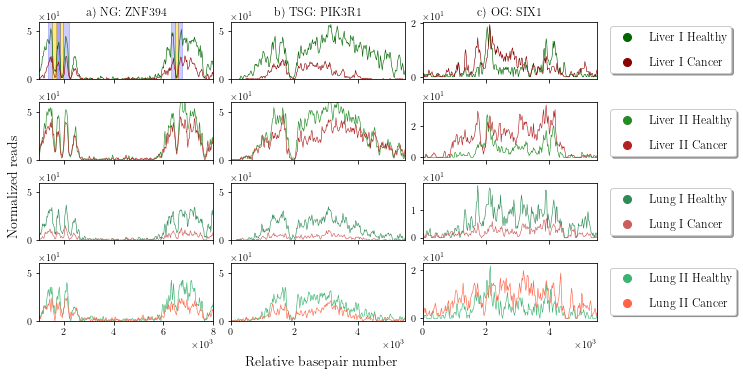

In [22]:
import matplotlib.lines as mlines

# Final sequences illustrated
track_list = [' Normal',' Cancer']

color_list = ['darkblue','cornflowerblue','deepskyblue','lightseagreen', 'aquamarine', 'lightskyblue', 'steelblue', 'indigo']
ls_list = ['dotted','dashed']
PATH = '/scratch/lema/marc/oncogenes/GSE67471/Final_sequences/'

labels = ['Liver_I', 'Liver_II', 'Lung_I', 'Lung_II']

name_list = [PATH+'Final_sequences_40kbp_{}.npy'.format(label) for label in labels]

# Handles

livI_healthy = mlines.Line2D([], [], color='darkgreen', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Liver','I','Healthy'))
livI_cancer = mlines.Line2D([], [], color='darkred', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Liver','I','Cancer'))
livII_healthy = mlines.Line2D([], [], color='forestgreen', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Liver','II','Healthy'))
livII_cancer = mlines.Line2D([], [], color='firebrick', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Liver','II','Cancer'))
lunI_healthy = mlines.Line2D([], [], color='seagreen', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Lung','I','Healthy'))
lunI_cancer = mlines.Line2D([], [], color='indianred', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Lung','I','Cancer'))
lunII_healthy = mlines.Line2D([], [], color='mediumseagreen', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Lung','II','Healthy'))
lunII_cancer = mlines.Line2D([], [], color='tomato', marker='o', linestyle='None',
                          markersize=8, label='{:8s}{:4s}{:10s}'.format('Lung','II', 'Cancer'))


fig = plt.figure(figsize=(10,5.5))
plt.ticklabel_format(style='sci', scilimits=(0,0))
grid = plt.GridSpec(4, 3, wspace=.1, hspace=0.4 )
first_bp = 0
last_bp = 10000
step = 20
lw =.7

#gene_limits_list = np.load('Training_Validation_genes_limits.npy')

xtrn = np.load(name_list[0])
plt.subplot(grid[0, 0])
element= 1355
shift=0
plt.title('a) NG: ZNF394')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0], color = 'darkgreen', alpha = 1., lw = 0.6, label = 'Liver I healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1], color = 'darkred', alpha = 1., lw = 0.6, label = 'Liver I cancer')
plt.axvspan(6450, 6570, color='gold', alpha=0.5)
plt.axvspan(1680,1850, color='blue', alpha=0.2)
plt.axvspan(1850,1980, color='gold', alpha=0.5)
plt.axvspan(1980,2200, color='blue', alpha=0.2)
plt.axvspan(1680,1850, color='blue', alpha=0.2)
plt.axvspan(1520,1680, color='gold', alpha=0.5)
plt.axvspan(6300,6450, color='blue', alpha=0.2)
plt.axvspan(6570,6730, color='blue', alpha=0.2)
plt.axvspan(1350,1520, color='blue', alpha=0.2)  
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xlim((1000,8000))
plt.ylim((0,60))
plt.yticks(ticks=[0,50])
plt.xticks(ticks=[2000,4000,6000,8000],labels=['','','',''])



#################################################################

xtrn = np.load(name_list[1])
plt.subplot(grid[1, 0])
element= 1355
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0], color = 'forestgreen', alpha=1., lw =0.6, label = 'Liver II healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1],  color = 'firebrick', alpha=1., lw =0.6, label = 'Liver II cancer')
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.ylim((0,60))
plt.yticks(ticks=[0,50])
plt.xlim((1000,8000))
plt.xticks(ticks=[2000,4000,6000,8000],labels=['','','',''])

###############################################################
xtrn = np.load(name_list[2])

plt.subplot(grid[2, 0])
element= 1355
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0], color = 'seagreen', alpha = 1., lw = 0.6, label = 'Lung I healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1], color = 'indianred', alpha = 1., lw = 0.6, label = 'Lung I cancer')
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xlim((1000,8000))
plt.ylim((0,60))
plt.yticks(ticks=[0,50])
plt.xticks(ticks=[2000,4000,6000,8000],labels=['','','',''])
#plt.ylabel('{} Normalized reads'.format('\t\t\t'), fontsize=14)

##############################################################
xtrn = np.load(name_list[3])

plt.subplot(grid[3, 0])
element= 1355
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0],color = 'mediumseagreen', alpha=1., lw =0.6, label = 'Lung II healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1], color = 'tomato', alpha=1., lw =0.6, label = 'Lung II cancer')
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[2000,4000,6000,8000])
plt.xlim((1000,8000))
plt.ylim((0,60))
plt.yticks(ticks=[0,50])
###########################################################################################################################################

xtrn = np.load(name_list[0])

plt.subplot(grid[0, 1])
element= 896
plt.title('b) TSG: PIK3R1')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0], color = 'darkgreen', alpha = 1., lw = 0.6, label = 'Liver I healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1], color = 'darkred', alpha = 1., lw = 0.6, label = 'Liver I cancer')
#plt.axvspan(1150, 1280, color='gold', )
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xlim((0,5500))
plt.ylim((0,60))
plt.yticks(ticks=[0,50])
plt.xticks(ticks=[0,2000,4000],labels=['','',''])
#################################################################

xtrn = np.load(name_list[1])

plt.subplot(grid[1, 1])
element= 896
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0],  color = 'forestgreen', alpha=1., lw =0.6, label = 'Liver II healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1], color = 'firebrick', alpha=1., lw =0.6, label = 'Liver II cancer')
#plt.axvspan(2200, 2330, color='gold', )
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xlim((0,5500))
plt.ylim((0,60))
plt.yticks(ticks=[0,50])
plt.xticks(ticks=[0,2000,4000],labels=['','',''])

###############################################################
xtrn = np.load(name_list[2])
plt.subplot(grid[2, 1])
element=896
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0],color = 'seagreen', alpha = 1., lw = 0.6, label = 'Lung I healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1],color = 'indianred', alpha = 1., lw = 0.6, label = 'Lung I cancer')
#plt.axvspan(1900, 2030, color='gold', )
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.ylim((0,60))
plt.yticks(ticks=[0,50])
plt.xlim((0,5500))
plt.xticks(ticks=[0,2000,4000],labels=['','',''])

#plt.ylabel('{} Normalized reads'.format('\t\t\t'), fontsize=14)

##############################################################
xtrn = np.load(name_list[3])
plt.subplot(grid[3, 1])
element=896
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0],color = 'mediumseagreen', alpha=1., lw =0.6, label = 'Lung II healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1], color = 'tomato', alpha=1., lw =0.6, label = 'Lung II cancer')
#plt.axvspan(2000, 2130, color='gold', )
plt.ylim((0,60))
plt.yticks(ticks=[0,50])
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000])
plt.xlim((0,5500))


####################################################################################################################################

xtrn = np.load(name_list[0])

plt.subplot(grid[0, 2])
element= 1073
plt.title('c) OG: SIX1') 
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0], color = 'darkgreen', alpha = 1., lw = 0.6, label = 'Liver I healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1], color = 'darkred', alpha = 1., lw = 0.6, label = 'Liver I cancer')
plt.ticklabel_format(style='sci', scilimits=(0,0))
#plt.xlim((0,5500))
#plt.ylim((0,120))
#plt.yticks(ticks=[0,100])
plt.xticks(ticks=[0,2000,4000] ,labels=['','',''])
plt.xlim((0,5500))
#################################################################

xtrn = np.load(name_list[1])

plt.subplot(grid[1, 2])
element= 1073
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0],  color = 'forestgreen', alpha=1., lw =0.6, label = 'Liver II healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1],  color = 'firebrick', alpha=1., lw =0.6, label = 'Liver II cancer')
plt.ticklabel_format(style='sci', scilimits=(0,0))
#plt.ylim((0,220))
#plt.yticks(ticks=[0,200])
plt.xticks(ticks=[0,2000,4000] ,labels=['','',''])
plt.xlim((0,5500))
###############################################################
xtrn = np.load(name_list[2])

plt.subplot(grid[2, 2])
element= 1073
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0],color = 'seagreen', alpha = 1., lw = 0.6, label = 'Lung I healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1], color = 'indianred', alpha = 1., lw = 0.6, label = 'Lung I cancer')
plt.ticklabel_format(style='sci', scilimits=(0,0))
#plt.xlim((0,5500))
#plt.ylim((0,120))
#plt.yticks(ticks=[0,100])
plt.xticks(ticks=[0,2000,4000] ,labels=['','',''])
plt.xlim((0,5500))
#plt.ylabel('{} Normalized reads'.format('\t\t\t'), fontsize=14)

##############################################################

xtrn = np.load(name_list[3])
plt.subplot(grid[3, 2])
element= 1073

plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,0])),xtrn[element,first_bp:last_bp:step,0],color = 'mediumseagreen', alpha=1., lw =0.6, label = 'Lung II healthy')
plt.plot(shift+step*np.arange(len(xtrn[element,first_bp:last_bp:step,1])),xtrn[element,first_bp:last_bp:step,1], color = 'tomato', alpha=1., lw =0.6, label = 'Lung II cancer')
#plt.xlim((0,5500))
#plt.ylim((0,120))
#plt.yticks(ticks=[0,100])
plt.ticklabel_format(style='sci', scilimits=(0,0))
plt.xticks(ticks=[0,2000,4000])
plt.xlim((0,5500))


# Legend:
x=110
y=50
#plt.text(-750+x+20, 1780, 'Healthy:', color='black')
#plt.text(-600+x, 1765, '-', color='darkblue', size=180)
#plt.text(-550+x, 1765, '-', color='darkgreen', size=180)
#plt.text(-500+x, 1765, '-', color='darkmagenta', size=180)
#plt.text(-380+y+10, 1780, 'Cancer:', color='black')
#plt.text(-250+y, 1765, '-', color='darkorange', size=180)
#plt.text(-200+y, 1765, '-', color='darkred', size=180)
#plt.text(-150+y, 1765, '-', color='darkcyan', size=180)
plt.text(-3200, -20, 'Relative basepair number', ha='center', fontsize=14)
plt.text(-13100, 55, 'Normalized reads', va='center', rotation='vertical', fontsize=14)
fig.legend(loc='center left',bbox_to_anchor=(.91, .81), labelspacing =1,
          ncol=1, fancybox=True, shadow=True, fontsize=12, handles = [livI_healthy,livI_cancer])
fig.legend(loc='center left',bbox_to_anchor=(.91, .60), labelspacing =1,
          ncol=1, fancybox=True, shadow=True, fontsize=12, handles = [livII_healthy,livII_cancer])
fig.legend(loc='center left',bbox_to_anchor=(.91, .40), labelspacing =1,
          ncol=1, fancybox=True, shadow=True, fontsize=12, handles = [lunI_healthy,lunI_cancer])
fig.legend(loc='center left',bbox_to_anchor=(.91, .20), labelspacing =1,
          ncol=1, fancybox=True, shadow=True, fontsize=12, handles = [lunII_healthy,lunII_cancer])
plt.savefig('Shifted_structure.png', dpi=250, bbox_inches='tight')
plt.show()

# Performance evaluation: Confusion matrices, ROC and AUPRC.

In [24]:
def binary_pred_stats(ytrue, ypred, threshold=0.5):
    """ Function that, from the true labels and the predicted model outputs, gives us
        the main performance metrics. Mattias Ohlsson's code"""
    one_correct = np.sum((ytrue==1)*(ypred > threshold))
    zero_correct = np.sum((ytrue==0)*(ypred <= threshold))
    sensitivity = one_correct / np.sum(ytrue==1)
    specificity = zero_correct / np.sum(ytrue==0)
    accuracy = (one_correct + zero_correct) / len(ytrue)
    precision = one_correct / np.sum(ypred > threshold)
    return sensitivity, specificity, accuracy, precision


def plot_confusion_matrix(cm,
                          target_names,
                          cell_line,
                          sample,
                          savepath,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    
    """ Function that plots the confusion matrix given cm. Mattias Ohlsson's code."""

    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(3.5,2.625))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    #plt.title(title)
    mincm = str(np.min(cm))
    maxcm = str(np.max(cm))
    print(mincm,maxcm)
    plt.colorbar()
    #plt.colorbar(ticks=[mincm,maxcm])
    #cbar.ax.tick_params(labelsize=14) 

    #plt.ylim([-0.5, cm.shape[0]-0.5])

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=0, fontsize=12)
        plt.yticks(tick_marks, target_names,fontsize=12)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 1.6
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black", fontsize=14)
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black", fontsize=14)


    plt.tight_layout()
    plt.ylabel('True label', fontsize=14)
    plt.xlabel('Predicted label', fontsize=14)
    plt.savefig(savepath+'{}_{}_Confusion_Test.png'.format(cell_line,sample), dpi=250, bbox_inches='tight')
    plt.show()
    



175 552


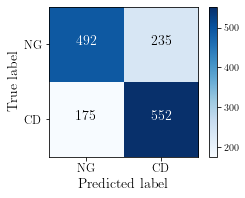

#####################Lung_I ################
Sn 0.7592847317744154	 Sp 0.6767537826685007	 Acc 0.7180192572214581	 Prec 0.7013977128335451
Sn 0.40715268225584594	 Sp 0.9037138927097662	 Acc 0.655433287482806	 Prec 0.8087431693989071
161 566


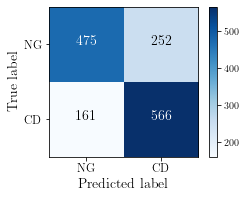

#####################Lung_II ################
Sn 0.7785419532324622	 Sp 0.6533700137551581	 Acc 0.7159559834938102	 Prec 0.6919315403422983
Sn 0.40990371389270974	 Sp 0.8913342503438789	 Acc 0.6506189821182944	 Prec 0.7904509283819628
176 551


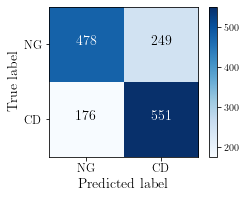

#####################Liver_I ################
Sn 0.7579092159559835	 Sp 0.657496561210454	 Acc 0.7077028885832187	 Prec 0.68875
Sn 0.3810178817056396	 Sp 0.9147180192572214	 Acc 0.6478679504814305	 Prec 0.8171091445427728
172 555


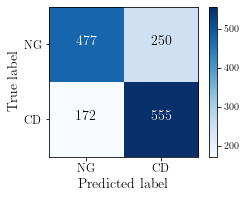

#####################Liver_II ################
Sn 0.7634112792297112	 Sp 0.656121045392022	 Acc 0.7097661623108665	 Prec 0.6894409937888198
Sn 0.3768913342503439	 Sp 0.9023383768913342	 Acc 0.6396148555708391	 Prec 0.7942028985507247
180 547


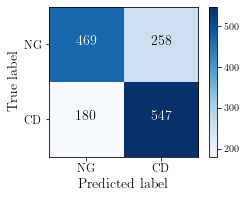

#####################NT2D1_I ################
Sn 0.7524071526822559	 Sp 0.6451169188445667	 Acc 0.6987620357634112	 Prec 0.6795031055900621
Sn 0.2874828060522696	 Sp 0.9023383768913342	 Acc 0.5949105914718019	 Prec 0.7464285714285714
91 283


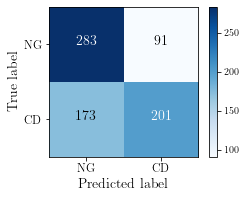

#####################Liver_II_specific ################
Sn 0.5374331550802139	 Sp 0.7566844919786097	 Acc 0.6470588235294118	 Prec 0.6883561643835616
Sn 0.28609625668449196	 Sp 0.9171122994652406	 Acc 0.6016042780748663	 Prec 0.7753623188405797
Lung      I           (AUC =0.79)
Lung      II          (AUC =0.78)
Liver     I           (AUC =0.78)
Liver     II          (AUC =0.78)
NT2D1     I           (AUC =0.76)
Liver     II          (AUC =0.70)
[0.7880277146570955, 0.780687530863964, 0.7837299372409083, 0.7755487399934535, 0.7591068796603402, 0.6966956447138895]


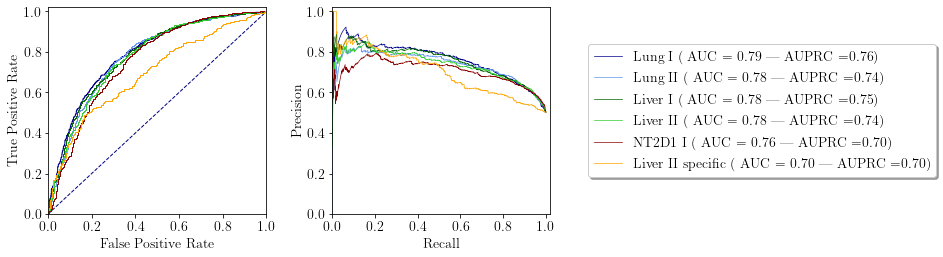

In [27]:
# ROC curve and AUC:
import os
import random as rnd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

PATH = '/home/william/marc/marc_directory/OriGENE_paper/Code/'

directory =  [f.name for f in os.scandir(PATH)]
target_names = ['NG','CD']
savepath = '/home/william/marc/marc_directory/OriGENE_paper/Images/'
cell_line_list = ['Lung_I','Lung_II','Liver_I','Liver_II','NT2D1_I', 'Liver_II_specific']#, 'Liver']#,'Lung']
sample_list = ['H3K4me3','H3K9ac','H3K36me3','H3K9me3','H3K27me3','H3K4me1']#,'Normal_I']#,'Normal_I']
label_list = ['Lung_I','Lung_II','Liver_I','Liver_II','NT2D1_I', 'Liver_II_specific']

color_list = ['darkblue', 'cornflowerblue','darkgreen','limegreen','darkred','orange','gold', 'navajowhite' ]

fpr_list = []
tpr_list = []
roc_auc_list = []

precision_list = []
recall_list = []
auprc_list = []
bootstrap_list = []
new_file = 'Performance_metrics_40kb_singletrack.tsv'

with open(new_file,'w') as f1:
    #f1.write('{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n'.format(tissue,'Threshold','Sensitivity (Sn)','Specificity (Sp)','Accuracy (Acc)','Precision (Pr)', 'AUC', '90% C.I','AUPRC'))

    for tissue in cell_line_list:

        if 'OriGENE_{}_40kbp_singletrack_ypred.npy'.format(tissue) in directory:
            if tissue == 'Liver II_specific':
                label_list.append('{:10s} {:10s} {:10s}'.format(tissue.split('_')[0],tissue.split('_')[1],tissue.split('_')[1]))
            else:
                label_list.append('{:10s} {:10s}'.format(tissue.split('_')[0],tissue.split('_')[1]))
        
            #y_pred = np.load('OriGENE_truestart_NT2D1_multiple_40kb_{}_{}_ypred.npy'.format(tissue,sample))
            #y_true = np.load('OriGENE_truestart_NT2D1_multiple_40kb_{}_{}_ytrue.npy'.format(tissue,sample))
            y_pred = np.load('OriGENE_{}_40kbp_singletrack_ypred.npy'.format(tissue))
            y_true = np.load('OriGENE_{}_40kbp_singletrack_ytrue.npy'.format(tissue))
            fpr,tpr,thresholds = roc_curve(y_true, y_pred)
            precision, recall, prc_thresholds = precision_recall_curve(y_true, y_pred)

            roc_auc = auc(fpr, tpr)
            auprc = auc(recall,precision)

            fpr_list.append(fpr)
            tpr_list.append(tpr)
            roc_auc_list.append(roc_auc)
            precision_list.append(precision)
            recall_list.append(recall)
            auprc_list.append(auprc)



            threshold = 0.5
            y_pred_bin = np.array([round(x) for x in y_pred])
            confusion = confusion_matrix(y_true, y_pred_bin)

            plot_confusion_matrix(confusion,
                                  target_names,
                                  cell_line=tissue,
                                  sample='singletrack_{}_final_5kbp'.format(tissue),
                                  savepath=savepath,
                                  title='Confusion matrix',
                                  cmap=None,
                                  normalize=False)


        ############## AUC confidence bounds 90%  ###############################
            # obtained from https://stackoverflow.com/questions/19124239/scikit-learn-roc-curve-with-confidence-intervals
            n_bootstraps = 1000
            rng_seed = 42  # control reproducibility
            bootstrapped_scores = []

            rng = np.random.RandomState(rng_seed)
            for i in range(n_bootstraps):
                # bootstrap by sampling with replacement on the prediction indices
                indices = rng.randint(0, len(y_pred), len(y_pred))
                if len(np.unique(y_true[indices])) < 2:
                    # We need at least one positive and one negative sample for ROC AUC
                    # to be defined: reject the sample
                    continue

                score = roc_auc_score(y_true[indices], y_pred[indices])
                bootstrapped_scores.append(score)
                #print("Bootstrap #{} ROC area: {:0.3f}".format(i + 1, score))

            sorted_scores = np.array(bootstrapped_scores)
            bootstrap_list.append(sorted_scores)
            sorted_scores.sort()

            # Computing the lower and upper bound of the 90% confidence interval
            # You can change the bounds percentiles to 0.025 and 0.975 to get
            # a 95% confidence interval instead.
            confidence_lower = sorted_scores[int(0.05 * len(sorted_scores))]
            confidence_upper = sorted_scores[int(0.95 * len(sorted_scores))]


            print('#####################{} ################'.format(tissue))

            for thr in [0.5,0.75]:
                sensitivity, specificity, accuracy, precision = binary_pred_stats(y_true,y_pred,threshold=thr)
                print('Sn {}\t Sp {}\t Acc {}\t Prec {}'.format(sensitivity, specificity, accuracy, precision))
                f1.write('{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n'.format(tissue,thr,sensitivity,specificity,accuracy,precision, roc_auc, '[{:0.3f} - {:0.3}]'.format(confidence_lower, confidence_upper) , auprc))

plt.figure(figsize=(9,3.8))
grid = plt.GridSpec(1, 2, wspace=.3, hspace=2.)

lw = 1
plt.subplot(grid[0, 0])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
for i in range(len(roc_auc_list)):
    label = '{:10s}{:12s}(AUC ={:.2f})'.format(label_list[i].split('_')[0],label_list[i].split('_')[1], roc_auc_list[i])
    print(label)
    plt.plot(fpr_list[i], tpr_list[i],lw=lw, label=label, color = color_list[i])
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
#plt.title('Receiver operating characteristic example')
#plt.legend(loc='lower right',
#          ncol=1, fancybox=True, shadow=False, fontsize=10)
#plt.savefig(savepath+'ROC_5kb_singletrack.png',dpi=200, bbox_inches='tight')
#plt.show()
print(roc_auc_list)


plt.subplot(grid[0, 1])
lw = .7
for i in range(len(auprc_list)):
    if i == (len(auprc_list)-1):
        label = '{:8s}{:9s}{:9s}( AUC = {:.2f} | AUPRC ={:.2f})'.format(label_list[i].split('_')[0],label_list[i].split('_')[1],label_list[i].split('_')[2], roc_auc_list[i], auprc_list[i])
    else:
        label = '{:8s}{:9s}( AUC = {:.2f} | AUPRC ={:.2f})'.format(label_list[i].split('_')[0],label_list[i].split('_')[1], roc_auc_list[i], auprc_list[i])
    plt.plot(recall_list[i], precision_list[i],lw=lw, label=label, color = color_list[i])
plt.xlim([0.0, 1.02])
plt.ylim([0.0, 1.02])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
#plt.title('Receiver operating characteristic example')
plt.legend(loc='right', bbox_to_anchor = (2.8,.5),
          ncol=1, fancybox=True, shadow=True, fontsize=14)
plt.savefig('Single_track_40kbp_ROC_AUPRC.png',dpi=300, bbox_inches='tight')
plt.show()



153 574


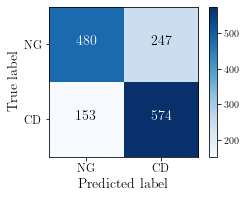

#####################Lung_I ################
Sn 0.7895460797799174	 Sp 0.6602475928473177	 Acc 0.7248968363136176	 Prec 0.6991473812423873
Sn 0.36451169188445665	 Sp 0.9092159559834938	 Acc 0.6368638239339752	 Prec 0.8006042296072508
149 578


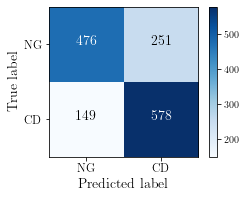

#####################Lung_II ################
Sn 0.7950481430536451	 Sp 0.6547455295735901	 Acc 0.7248968363136176	 Prec 0.6972255729794934
Sn 0.37276478679504815	 Sp 0.9037138927097662	 Acc 0.6382393397524071	 Prec 0.7947214076246334
166 561


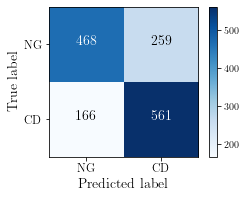

#####################Liver_I ################
Sn 0.7716643741403026	 Sp 0.6437414030261348	 Acc 0.7077028885832187	 Prec 0.6841463414634147
Sn 0.39614855570839064	 Sp 0.8940852819807428	 Acc 0.6451169188445667	 Prec 0.7890410958904109
178 549


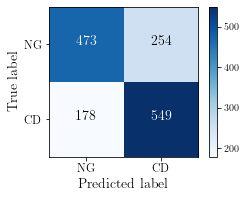

#####################Liver_II ################
Sn 0.7551581843191196	 Sp 0.6506189821182944	 Acc 0.7028885832187071	 Prec 0.6836861768368617
Sn 0.38651994497936726	 Sp 0.9037138927097662	 Acc 0.6451169188445667	 Prec 0.8005698005698005
187 540


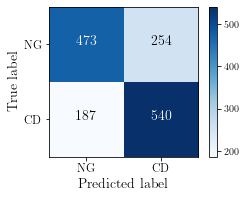

#####################NT2D1_I_all ################
Sn 0.7427785419532325	 Sp 0.6506189821182944	 Acc 0.6966987620357634	 Prec 0.6801007556675063
Sn 0.38514442916093533	 Sp 0.8817056396148556	 Acc 0.6334250343878954	 Prec 0.7650273224043715
127 247


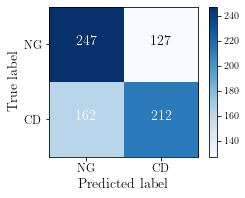

#####################Liver_II_specific ################
Sn 0.5668449197860963	 Sp 0.660427807486631	 Acc 0.6136363636363636	 Prec 0.6253687315634219
Sn 0.31016042780748665	 Sp 0.8850267379679144	 Acc 0.5975935828877005	 Prec 0.7295597484276729


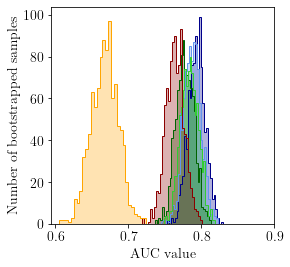

Lung     I    (AUC =0.79)
Lung     II   (AUC =0.79)
Liver    I    (AUC =0.78)
Liver    II   (AUC =0.78)
NT2-D1    (AUC =0.76)
Liver    II specific(AUC =0.67)
[0.7935458603028405, 0.78749132024922, 0.7772742839087354, 0.7839702267992863, 0.7636477847005556, 0.6667762875689897]


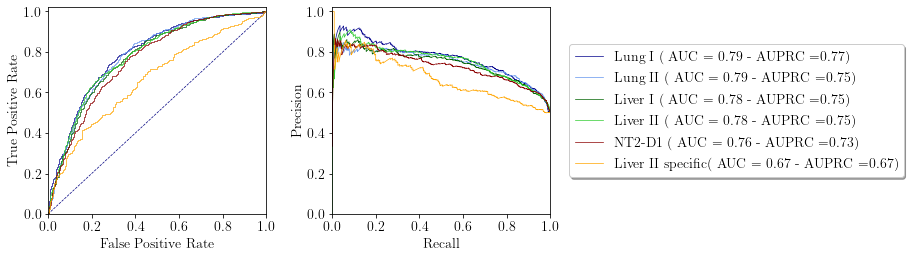

In [32]:
# ROC curve and AUC:
import os
import random as rnd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

PATH = '/home/william/marc/marc_directory/OriGENE_paper/Code/'

directory =  [f.name for f in os.scandir(PATH)]
target_names = ['NG','CD']
savepath = '/home/william/marc/marc_directory/OriGENE_paper/Images/'
cell_line_list = ['Lung_I','Lung_II','Liver_I','Liver_II','NT2D1_I_all', 'Liver_II_specific']#, 'Liver']#,'Lung']
sample_list = []#,'Normal_I']#,'Normal_I']
label_list = []#,'Liver II','Lung I','Lung II']

color_list = ['darkblue', 'cornflowerblue','darkgreen','limegreen','darkred','orange','gold', 'navajowhite' ]

fpr_list = []
tpr_list = []
roc_auc_list = []
bootstrap_list = []

precision_list = []
recall_list = []
auprc_list = []

new_file = 'Performance_metrics_40kb.tsv'

with open(new_file,'w') as f1:
    f1.write('{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n'.format(tissue,'Threshold','Sensitivity (Sn)','Specificity (Sp)','Accuracy (Acc)','Precision (Pr)', 'AUC', '90% C.I','AUPRC'))
    for tissue in cell_line_list:
        if 'OriGENE_{}_ypred.npy'.format(tissue) in directory:
            if tissue == 'Liver_II_specific':
                label_list.append('{:8s} {:2s} {:5s}'.format(tissue.split('_')[0],tissue.split('_')[1],tissue.split('_')[2]))
            elif tissue == 'NT2D1_I_all':
                label_list.append('NT2-D1')
            else:
                label_list.append('{:8s} {:5s}'.format(tissue.split('_')[0],tissue.split('_')[1]))

            #y_pred = np.load('OriGENE_truestart_NT2D1_multiple_40kb_{}_{}_ypred.npy'.format(tissue,sample))
            #y_true = np.load('OriGENE_truestart_NT2D1_multiple_40kb_{}_{}_ytrue.npy'.format(tissue,sample))
            y_pred = np.load('OriGENE_{}_ypred.npy'.format(tissue))
            y_true = np.load('OriGENE_{}_ytrue.npy'.format(tissue))
            fpr,tpr,thresholds = roc_curve(y_true, y_pred)
            precision, recall, prc_thresholds = precision_recall_curve(y_true, y_pred)

            roc_auc = auc(fpr, tpr)
            auprc = auc(recall,precision)

            fpr_list.append(fpr)
            tpr_list.append(tpr)
            roc_auc_list.append(roc_auc)
            precision_list.append(precision)
            recall_list.append(recall)
            auprc_list.append(auprc)



            threshold = 0.5
            y_pred_bin = np.array([round(x) for x in y_pred])
            confusion = confusion_matrix(y_true, y_pred_bin)

            plot_confusion_matrix(confusion,
                                  target_names,
                                  cell_line=tissue,
                                  sample='final_40kbp',
                                  savepath=savepath,
                                  title='Confusion matrix',
                                  cmap=None,
                                  normalize=False)

        ############## AUC confidence bounds 90%  ###############################
            # obtained from https://stackoverflow.com/questions/19124239/scikit-learn-roc-curve-with-confidence-intervals
            n_bootstraps = 1000
            rng_seed = 42  # control reproducibility
            bootstrapped_scores = []

            rng = np.random.RandomState(rng_seed)
            for i in range(n_bootstraps):
                # bootstrap by sampling with replacement on the prediction indices
                indices = rng.randint(0, len(y_pred), len(y_pred))
                if len(np.unique(y_true[indices])) < 2:
                    # We need at least one positive and one negative sample for ROC AUC
                    # to be defined: reject the sample
                    continue

                score = roc_auc_score(y_true[indices], y_pred[indices])
                bootstrapped_scores.append(score)
                #print("Bootstrap #{} ROC area: {:0.3f}".format(i + 1, score))

            sorted_scores = np.array(bootstrapped_scores)
            bootstrap_list.append(sorted_scores)
            sorted_scores.sort()

            # Computing the lower and upper bound of the 90% confidence interval
            # You can change the bounds percentiles to 0.025 and 0.975 to get
            # a 95% confidence interval instead.
            confidence_lower = sorted_scores[int(0.05 * len(sorted_scores))]
            confidence_upper = sorted_scores[int(0.95 * len(sorted_scores))]


            print('#####################{} ################'.format(tissue))

            for thr in [0.5,0.75]:
                sensitivity, specificity, accuracy, precision = binary_pred_stats(y_true,y_pred,threshold=thr)
                print('Sn {}\t Sp {}\t Acc {}\t Prec {}'.format(sensitivity, specificity, accuracy, precision))
                f1.write('{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\t{}\n'.format(tissue,thr,sensitivity,specificity,accuracy,precision, roc_auc, '[{:0.3f} - {:0.3}]'.format(confidence_lower, confidence_upper) , auprc))


plt.figure(figsize=(4,4))    
for i in range(len(bootstrap_list)):
    plt.hist(bootstrap_list[i], bins= 30, histtype='stepfilled', color= color_list[i], alpha = 0.3)
    plt.hist(bootstrap_list[i], bins= 30, histtype='step', color= color_list[i])
#plt.title('Histogram of the bootstrapped ROC AUC scores')
plt.xticks([.6,.7,.8,.9],fontsize = 14)
plt.yticks(fontsize=14)
plt.xlabel('AUC value', fontsize=14)
plt.ylabel('Number of bootstrapped samples', fontsize=14)
plt.savefig(savepath+'Bootstraped_histograms_example.png',dpi=500, bbox_inches='tight')
plt.show()
                
                
                
plt.figure(figsize=(9,3.8))
grid = plt.GridSpec(1, 2, wspace=.3, hspace=2.)

lw = .7
plt.subplot(grid[0, 0])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
for i in range(len(roc_auc_list)):

    label = '{:10s}(AUC ={:.2f})'.format(label_list[i], roc_auc_list[i])
    print(label)
    plt.plot(fpr_list[i], tpr_list[i],lw=lw, label=label, color = color_list[i])
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
#plt.title('Receiver operating characteristic example')
#plt.legend(loc='lower right',
#          ncol=1, fancybox=True, shadow=False, fontsize=10)
#plt.savefig(savepath+'ROC_5kb_singletrack.png',dpi=200, bbox_inches='tight')
#plt.show()
print(roc_auc_list)


plt.subplot(grid[0, 1])
for i in range(len(auprc_list)):
    label = '{:10s}( AUC = {:.2f} - AUPRC ={:.2f})'.format(label_list[i], roc_auc_list[i], auprc_list[i])
    plt.plot(recall_list[i], precision_list[i],lw=lw, label=label, color = color_list[i])
plt.xlim([0.0, 1.00])
plt.ylim([0.0, 1.02])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
#plt.title('Receiver operating characteristic example')
plt.legend(loc='right', bbox_to_anchor = (2.65,.5),
          ncol=1, fancybox=True, shadow=True, fontsize=14)
plt.savefig('All_track_ROC_AUPRC.png',dpi=300, bbox_inches='tight')
plt.show()

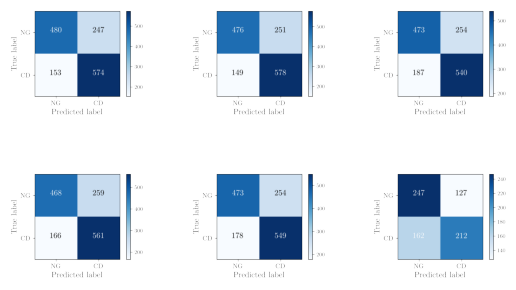

In [30]:
plt.figure(figsize=(9,6))
grid = plt.GridSpec(2, 3, wspace=.3, hspace=.001)
cell_line_list = ['Lung_I','Lung_II','NT2D1_I_all', 'Liver_I','Liver_II', 'Liver_II_specific']#
path = '/home/william/marc/marc_directory/OriGENE_paper/Images/'

grid_list = [[0,0],[0,1],[0,2],[1,0],[1,1],[1,2]]

for k,tissue in enumerate(cell_line_list):
    plt.subplot(grid[grid_list[k][0], grid_list[k][1]])
    plt.axis('off')
    img = plt.imread(path+'{}_final_40kbp_Confusion_Test.png'.format(tissue))
    plt.imshow(img)
plt.savefig('40kb_confusion.png', dpi = 250)

# Cross-tissue prediction

189 538


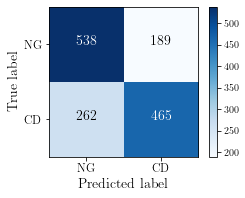

200 527


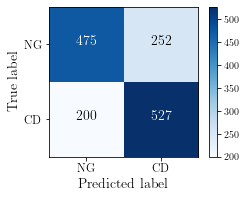

221 506


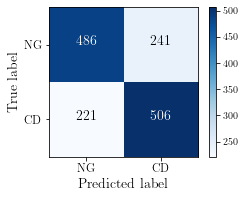

153 574


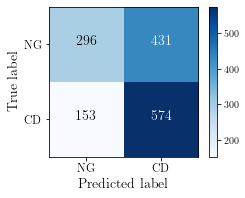

Lung     II   (AUC =0.74)
Liver    I    (AUC =0.74)
Liver    II   (AUC =0.73)
NT2-D1    (AUC =0.64)
[0.7435675242039699, 0.7402488794370791, 0.7342520467183448, 0.6447687827914835]


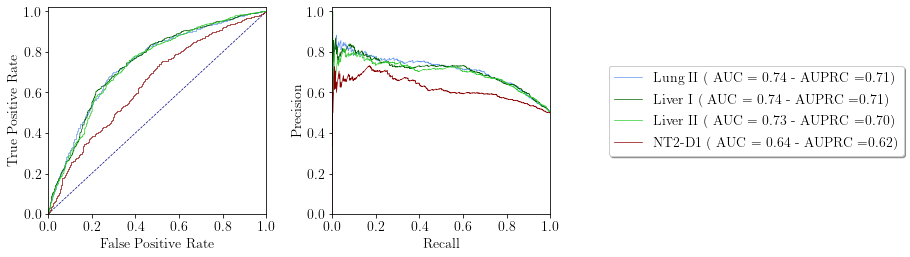

[0.10373697 0.14376596 0.14559519 ... 0.83562315 0.87880409 0.91183609]


In [31]:
# ROC curve and AUC:
import os
import random as rnd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score

PATH = '/home/william/marc/marc_directory/OriGENE_paper/Code/'

directory =  [f.name for f in os.scandir(PATH)]
target_names = ['NG','CD']
savepath = '/home/william/marc/marc_directory/OriGENE_paper/Images/Cross-tissue/'
cell_line_list = ['Lung_I','Lung_II','Liver_I','Liver_II','NT2D1_I']#, 'Liver']#,'Lung']
sample_list = []#,'Normal_I']#,'Normal_I']
label_list = []#,'Liver II','Lung I','Lung II']

color_list = ['cornflowerblue','darkgreen','limegreen','darkred','orange','gold', 'navajowhite' ]

fpr_list = []
tpr_list = []
roc_auc_list = []


precision_list = []
recall_list = []
auprc_list = []


for tissue in cell_line_list:
    if 'OriGENE_Lung_I_cross_tissue_5kbp_predicting_{}_genes.npy'.format(tissue) in directory:
        if tissue == 'NT2D1_I':
            label_list.append('NT2-D1')
        else:
            label_list.append('{:8s} {:5s}'.format(tissue.split('_')[0],tissue.split('_')[1]))

        #y_pred = np.load('OriGENE_truestart_NT2D1_multiple_40kb_{}_{}_ypred.npy'.format(tissue,sample))
        #y_true = np.load('OriGENE_truestart_NT2D1_multiple_40kb_{}_{}_ytrue.npy'.format(tissue,sample))
        y_pred = np.load('OriGENE_Lung_I_cross_tissue_5kbp_predicting_{}_ypred.npy'.format(tissue))
        y_true = np.load('OriGENE_Lung_I_cross_tissue_5kbp_predicting_{}_ytrue.npy'.format(tissue))
        fpr,tpr,thresholds = roc_curve(y_true, y_pred)
        precision, recall, prc_thresholds = precision_recall_curve(y_true, y_pred)

        roc_auc = auc(fpr, tpr)
        auprc = auc(recall,precision)

        fpr_list.append(fpr)
        tpr_list.append(tpr)
        roc_auc_list.append(roc_auc)
        precision_list.append(precision)
        recall_list.append(recall)
        auprc_list.append(auprc)



        threshold = 0.5
        y_pred_bin = np.array([round(x) for x in y_pred])
        confusion = confusion_matrix(y_true, y_pred_bin)

        plot_confusion_matrix(confusion,
                              target_names,
                              cell_line=tissue,
                              sample='cross_tissue_5kbp',
                              savepath=savepath,
                              title='Confusion matrix',
                              cmap=None,
                              normalize=False)
            
plt.figure(figsize=(9,3.8))
grid = plt.GridSpec(1, 2, wspace=.3, hspace=2.)

lw = .7
plt.subplot(grid[0, 0])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
for i in range(len(roc_auc_list)):

    label = '{:10s}(AUC ={:.2f})'.format(label_list[i], roc_auc_list[i])
    print(label)
    plt.plot(fpr_list[i], tpr_list[i],lw=lw, label=label, color = color_list[i])
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
#plt.title('Receiver operating characteristic example')
#plt.legend(loc='lower right',
#          ncol=1, fancybox=True, shadow=False, fontsize=10)
#plt.savefig(savepath+'ROC_5kb_singletrack.png',dpi=200, bbox_inches='tight')
#plt.show()
print(roc_auc_list)


plt.subplot(grid[0, 1])
for i in range(len(auprc_list)):
    label = '{:10s}( AUC = {:.2f} - AUPRC ={:.2f})'.format(label_list[i], roc_auc_list[i], auprc_list[i])
    plt.plot(recall_list[i], precision_list[i],lw=lw, label=label, color = color_list[i])
plt.xlim([0.0, 1.00])
plt.ylim([0.0, 1.02])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
#plt.title('Receiver operating characteristic example')
plt.legend(loc='right', bbox_to_anchor = (2.65,.5),
          ncol=1, fancybox=True, shadow=True, fontsize=14)
plt.savefig(savepath+'Cross-tissue_ROC_AUPRC.png',dpi=300, bbox_inches='tight')
plt.show()
print(prc_thresholds)